# Air Quality in Nairobi

In [90]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# set visual style
sns.set_style("whitegrid")

In [91]:
air_data = pd.read_csv("data/nairobi_air_quality_2025.csv")
air_data.head()

,site_name,datetime,frequency,network,latitude,longitude,temperature,humidity,pm2_5
0,"Athi, Nairobi",2025-01-01 00:00:00+00:00,daily,airqo,-1.262956,37.091158,23.706405,69.324027,16.30
1,"Athi, Nairobi",2025-01-02 00:00:00+00:00,daily,airqo,-1.262956,37.091158,22.730201,67.361020,11.96
2,"Athi, Nairobi",2025-01-03 00:00:00+00:00,daily,airqo,-1.262956,37.091158,23.036989,65.819461,14.27
3,"Athi, Nairobi",2025-01-04 00:00:00+00:00,daily,airqo,-1.262956,37.091158,23.471478,66.173176,8.89
4,"Athi, Nairobi",2025-01-05 00:00:00+00:00,daily,airqo,-1.262956,37.091158,22.362268,69.583073,11.62


## 1. Data Cleaning

In [92]:
air_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2799 entries, 0 to 2798
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   site_name    2799 non-null   str    
 1   datetime     2799 non-null   str    
 2   frequency    2799 non-null   str    
 3   network      2799 non-null   str    
 4   latitude     2756 non-null   float64
 5   longitude    2756 non-null   float64
 6   temperature  2754 non-null   float64
 7   humidity     2697 non-null   float64
 8   pm2_5        2756 non-null   float64
dtypes: float64(5), str(4)
memory usage: 354.7 KB


In [93]:
# check for missing values
print("Missing values in each column:")
print(air_data.isnull().sum())

Missing values in each column:
site_name        0
datetime         0
frequency        0
network          0
latitude        43
longitude       43
temperature     45
humidity       102
pm2_5           43
dtype: int64


In [94]:
# separate to numerical and categorical columns
numerical_cols = air_data.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = air_data.select_dtypes(include=['str']).columns

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: Index(['latitude', 'longitude', 'temperature', 'humidity', 'pm2_5'], dtype='str')
Categorical columns: Index(['site_name', 'datetime', 'frequency', 'network'], dtype='str')


In [95]:
# impute missing values for numerical columns with mean
air_data[numerical_cols] = air_data[numerical_cols].fillna(air_data[numerical_cols].mean())

# check for missing values again
print("Missing values after imputation:")
print(air_data.isnull().sum())

Missing values after imputation:
site_name      0
datetime       0
frequency      0
network        0
latitude       0
longitude      0
temperature    0
humidity       0
pm2_5          0
dtype: int64


In [96]:
# check for duplicates
duplicates = air_data.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [97]:
# Convert the datetime column to actual pandas datetime objects
air_data['datetime'] = pd.to_datetime(air_data['datetime'])

# Clean string columns by stripping leading/trailing whitespace and standardizing case
categorical_cols = ['site_name', 'frequency', 'network']
for col in categorical_cols:
    if col in air_data.columns:
        air_data[col] = air_data[col].astype(str).str.strip().str.lower()

# Force conversion of numerical columns
numerical_cols = ['latitude', 'longitude', 'temperature', 'humidity', 'pm2_5']
for col in numerical_cols:
    if col in air_data.columns:
        air_data[col] = pd.to_numeric(air_data[col], errors='coerce')

air_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2799 entries, 0 to 2798
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   site_name    2799 non-null   str                
 1   datetime     2799 non-null   datetime64[us, UTC]
 2   frequency    2799 non-null   str                
 3   network      2799 non-null   str                
 4   latitude     2799 non-null   float64            
 5   longitude    2799 non-null   float64            
 6   temperature  2799 non-null   float64            
 7   humidity     2799 non-null   float64            
 8   pm2_5        2799 non-null   float64            
dtypes: datetime64[us, UTC](1), float64(5), str(3)
memory usage: 287.4 KB


In [98]:
# check for nunique values in each column
print("Number of unique values in each column:")
print(air_data.nunique())

# drop unnecessary columns
air_data = air_data.drop(columns=['frequency', 'network'])
print('--------------')
print('Constant values Columns dropped!')

Number of unique values in each column:
site_name        10
datetime        365
frequency         1
network           1
latitude        202
longitude       195
temperature    2387
humidity       2316
pm2_5          1859
dtype: int64
--------------
Constant values Columns dropped!


Outliers in numerical columns:
          latitude    longitude  temperature     humidity        pm2_5
count  2799.000000  2799.000000  2799.000000  2799.000000  2799.000000
mean     -0.738134    21.155724    19.717759    55.565959    23.503113
std       0.622933    17.847989     8.050702    24.320172    10.675728
min      -1.342420     0.000000     0.000000     0.000000     0.000000
1%       -1.342420     0.000000     0.000000     0.000000     6.895800
5%       -1.342420     0.000000     0.000000     0.000000    10.859000
10%      -1.292882     0.000000     0.000000     0.000000    12.998000
90%       0.000000    36.909322    24.996699    76.139113    36.282000
95%       0.000000    37.091158    25.911764    79.919497    40.745000
99%       0.000000    37.091158    29.457101    89.255467    54.353400
max       0.000000    37.091158    39.022485    98.690202   119.970000


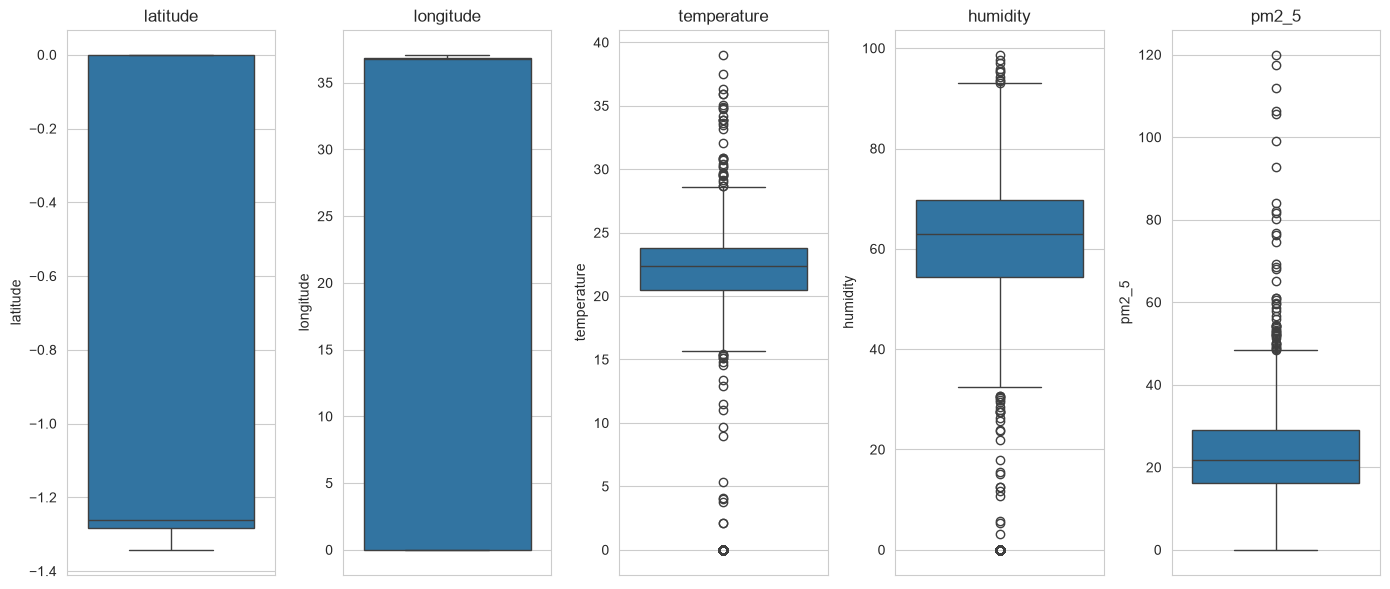

In [99]:
# managing outliers
# check for outliers in numerical columns
print("Outliers in numerical columns:")
print(air_data[numerical_cols].describe(percentiles=[0.01, 0.05, 0.1, 0.9, 0.95, 0.99]))

# Create boxplots to spot outliers visually
plt.figure(figsize=(14, 6))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, len(numerical_cols), i)
    sns.boxplot(y=air_data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [100]:
# IQR Method to remove the outliers
Q1 = air_data[numerical_cols].quantile(0.25)
Q3 = air_data[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

# Remove outliers
mask = ~((air_data[numerical_cols] < (Q1 - 1.5 * IQR)) | (air_data[numerical_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
air_data_clean = air_data[mask]

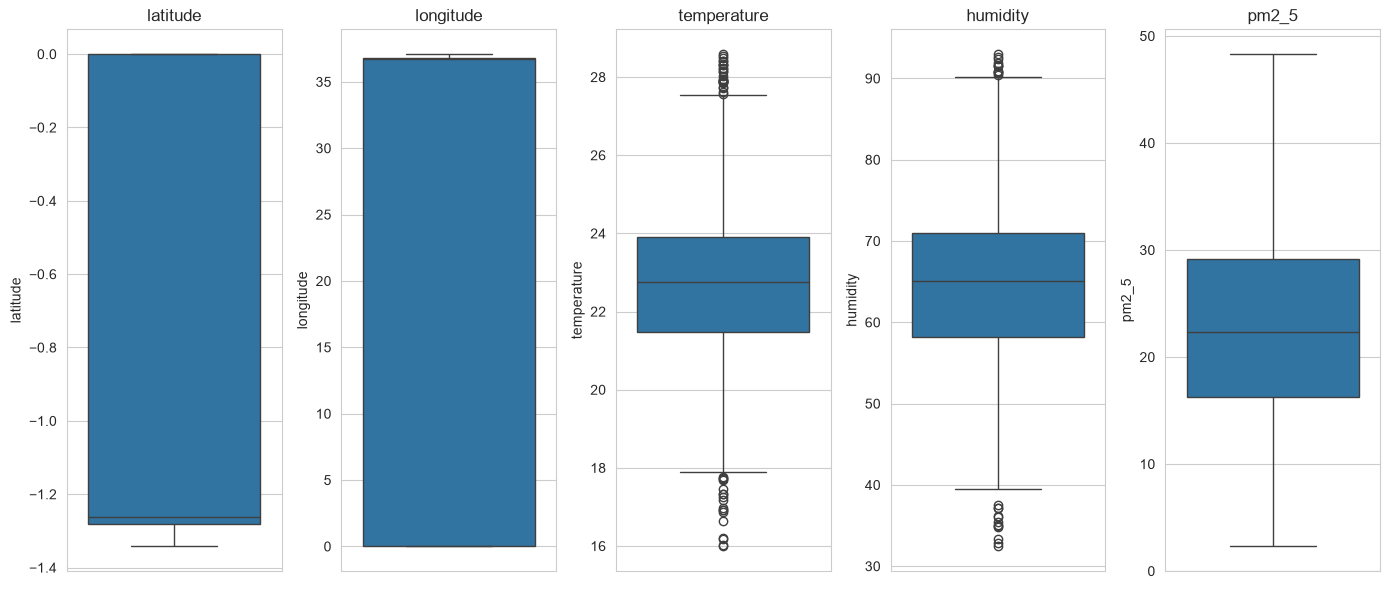

In [101]:
# boxplot to see if the outliers were removed
plt.figure(figsize=(14, 6))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, len(numerical_cols), i)
    sns.boxplot(y=air_data_clean[col])
    plt.title(col)

plt.tight_layout()
plt.show()

## 2. Data Preprocessing

In [102]:
# categorical variables
print('Categorical Columns:', air_data_clean.select_dtypes(include=['str']).columns)

# check for unique values for the categorical variables
for col in air_data_clean.select_dtypes(include=['str']).columns:
    print(col, ':', air_data_clean[col].nunique())
    print('-' * 50)
    print('The Unique values are:', air_data_clean[col].unique())

Categorical Columns: Index(['site_name'], dtype='str')
site_name : 10
--------------------------------------------------
The Unique values are: <ArrowStringArray>
[                     'athi, nairobi',        'birongo square nairobi west',
 'buruburu, makadara, nairobi, kenya',    'donholm, embakasi east, nairobi',
              'drumvale drive kamulu',              'fire station, nairobi',
       'kenyatta university, nairobi',                           'kiamaiko',
            'komarock nairobi, kenya',              'kuwinda lang'ata road']
Length: 10, dtype: str


In [103]:
# one hot encoding for site_name
air_data_clean = pd.get_dummies(air_data_clean, columns=['site_name'], drop_first=True)
air_data_clean.head(10)

,datetime,latitude,longitude,temperature,humidity,pm2_5,site_name_birongo square nairobi west,"site_name_buruburu, makadara, nairobi, kenya","site_name_donholm, embakasi east, nairobi",site_name_drumvale drive kamulu,"site_name_fire station, nairobi","site_name_kenyatta university, nairobi",site_name_kiamaiko,"site_name_komarock nairobi, kenya",site_name_kuwinda lang'ata road
0,2025-01-01 00:00:00+00:00,-1.262956,37.091158,23.706405,69.324027,16.30,False,False,False,False,False,False,False,False,False
1,2025-01-02 00:00:00+00:00,-1.262956,37.091158,22.730201,67.361020,11.96,False,False,False,False,False,False,False,False,False
2,2025-01-03 00:00:00+00:00,-1.262956,37.091158,23.036989,65.819461,14.27,False,False,False,False,False,False,False,False,False
3,2025-01-04 00:00:00+00:00,-1.262956,37.091158,23.471478,66.173176,8.89,False,False,False,False,False,False,False,False,False
4,2025-01-05 00:00:00+00:00,-1.262956,37.091158,22.362268,69.583073,11.62,False,False,False,False,False,False,False,False,False
5,2025-01-06 00:00:00+00:00,-1.262956,37.091158,21.517650,61.198722,19.50,False,False,False,False,False,False,False,False,False
6,2025-01-07 00:00:00+00:00,-1.262956,37.091158,21.919198,65.141121,22.10,False,False,False,False,False,False,False,False,False
7,2025-01-08 00:00:00+00:00,-1.262956,37.091158,23.423586,61.855695,17.28,False,False,False,False,False,False,False,False,False
8,2025-01-09 00:00:00+00:00,-1.262956,37.091158,24.756819,64.083678,13.61,False,False,False,False,False,False,False,False,False
9,2025-01-10 00:00:00+00:00,-1.262956,37.091158,23.324671,71.921863,10.47,False,False,False,False,False,False,False,False,False


In [104]:
# split the data into train and test
X = air_data_clean.drop(columns=['pm2_5'])
y = air_data_clean['pm2_5']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = X_train.drop(columns=['datetime'], errors='ignore')
X_test = X_test.drop(columns=['datetime'], errors='ignore')

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1852, 13)
Test shape: (463, 13)


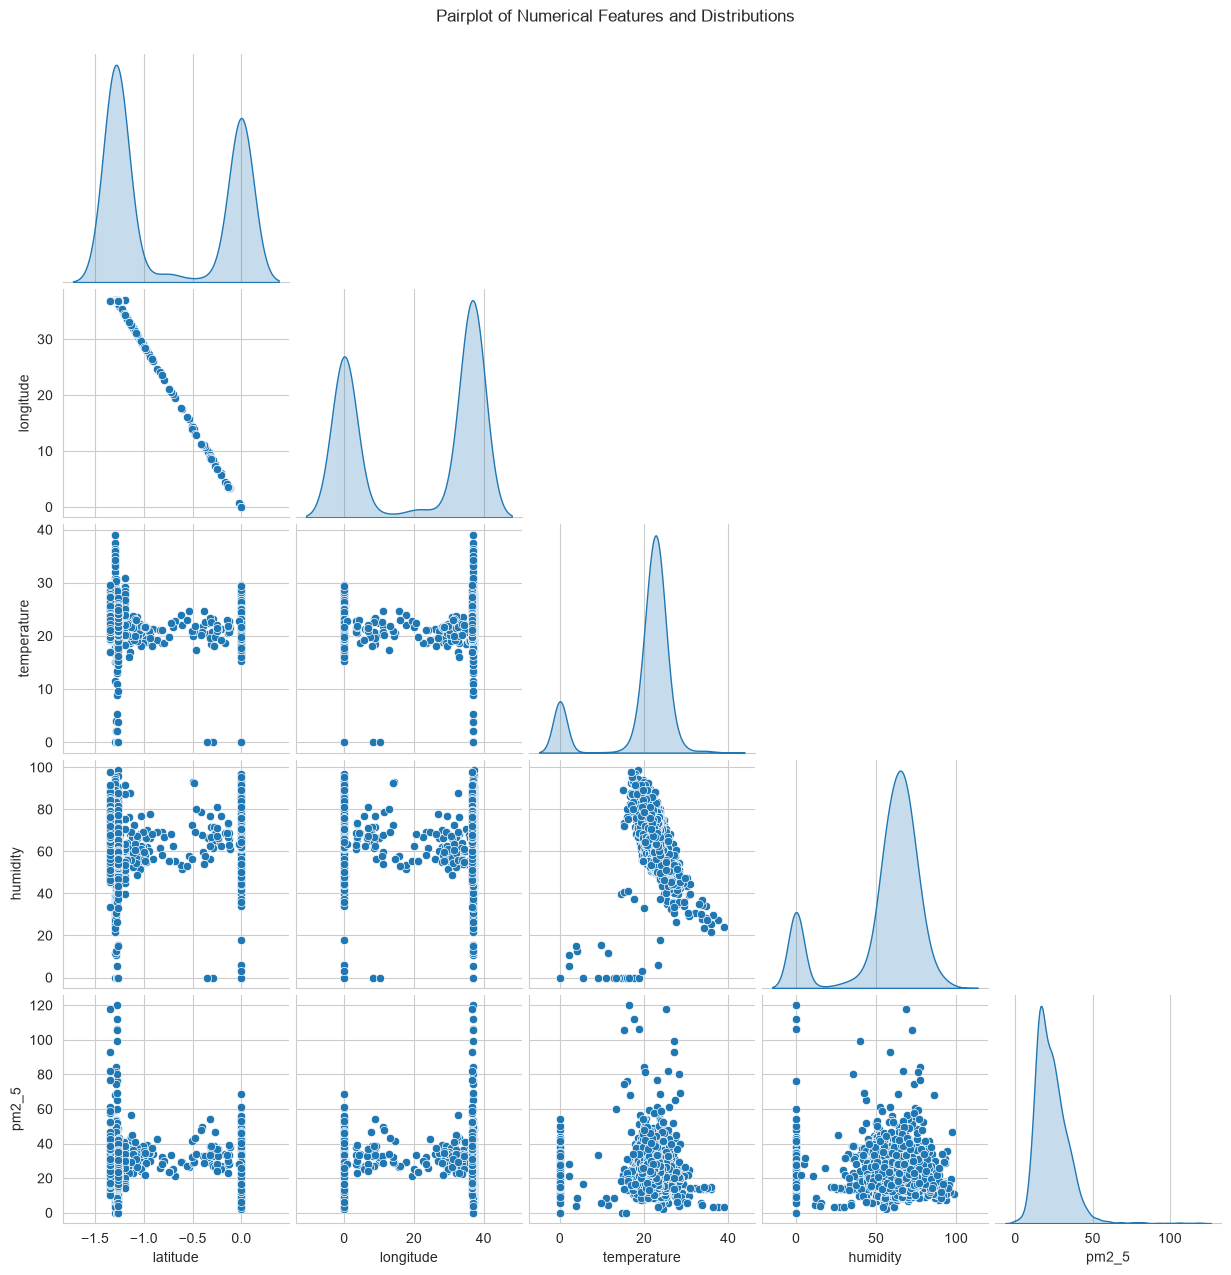

In [105]:
# feature distribution before scaling using pairplot
sns.pairplot(air_data, diag_kind='kde', corner=True)

plt.suptitle("Pairplot of Numerical Features and Distributions", y=1.02)
plt.show()

In [106]:
# feature scaling for the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3. Exploratory Data Analysis